Train samples: 2792  |  Test samples: 698

=== Fitting on train only ===
Epoch 1/50


/opt/miniconda3/envs/CQC24/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0391 - val_loss: 0.0012
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.1324e-04 - val_loss: 0.0012
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.0142e-04 - val_loss: 0.0012
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.8888e-04 - val_loss: 0.0011
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.7871e-04 - val_loss: 0.0011
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.7219e-04 - val_loss: 0.0011
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.6511e-04 - val_loss: 0.0010
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.5499e-04 - val_loss: 0.0010
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4571e-04 - val_loss: 0.0011
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.3196e-04 - val_loss: 0.0012
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.1357e-04 - val_loss: 0.0012
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms

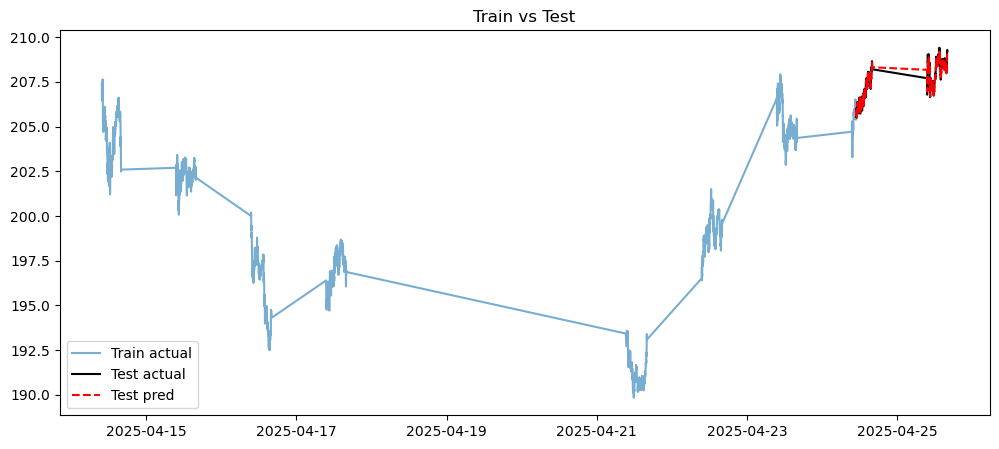

=== Retraining on full dataset for forecasting ===
Epoch 1/50


/opt/miniconda3/envs/CQC24/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0974
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0557e-04
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6029e-04
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.3854e-04
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2080e-04
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.9509e-04
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.5881e-04
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.1963e-04
Epoch 9/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.9022e-04
Epoch 10/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.8600e-04
Epoch 11/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.8004e-04
Epoch 12/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.6751e-04
Epoch 13/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.5261e-04
Epoch 14/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.3670e-04
Epoch 15/50
110/

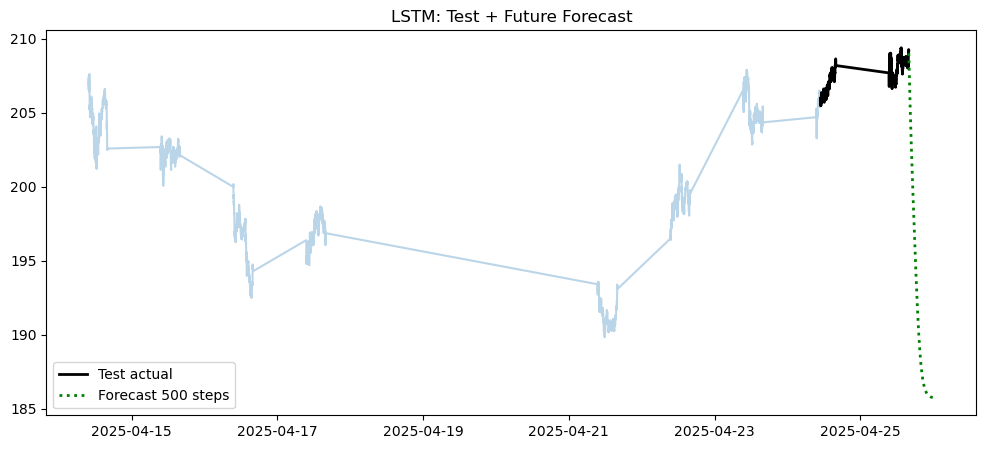

Future predictions:
2025-04-25 16:00:00    209.037079
2025-04-25 16:01:00    208.885483
2025-04-25 16:02:00    208.730225
2025-04-25 16:03:00    208.582306
2025-04-25 16:04:00    208.441803
                          ...    
2025-04-26 00:15:00    185.751251
2025-04-26 00:16:00    185.750793
2025-04-26 00:17:00    185.750320
2025-04-26 00:18:00    185.749863
2025-04-26 00:19:00    185.749420
Name: Predicted_Close, Length: 500, dtype: float32


In [16]:
### DECENT RMSE BAD PREDICTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# ─── 1. Load & prepare data ─────────────────────────────────────────────────────
df = pd.read_csv('HistoricalData/AAPL_ohlc_data.csv',
                 parse_dates=['DATE_TIME']).sort_values('DATE_TIME')
df.set_index('DATE_TIME', inplace=True)

# Keep just the closes
prices = df['CLOSE_PRICE'].values.reshape(-1,1)

# ─── 2. Scale ───────────────────────────────────────────────────────────────────
scaler = MinMaxScaler((0,1))
prices_s = scaler.fit_transform(prices)

# ─── 3. Sliding windows ─────────────────────────────────────────────────────────
def make_dataset(series, window=20):
    X,y = [],[]
    for i in range(len(series)-window):
        X.append(series[i:i+window,0])
        y.append(series[i+window,0])
    return np.array(X), np.array(y)

WINDOW = 20
X, y = make_dataset(prices_s, WINDOW)
# reshape for LSTM
X = X.reshape(len(X), WINDOW, 1)

# ─── 4. Train/Test split ─────────────────────────────────────────────────────────
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train samples: {len(X_train)}  |  Test samples: {len(X_test)}\n")

# ─── 5. Build & compile ──────────────────────────────────────────────────────────
def build_model():
    m = Sequential([
        LSTM(50, return_sequences=True, input_shape=(WINDOW,1)),
        LSTM(25),
        Dense(1)
    ])
    m.compile('adam','mse')
    return m

model = build_model()

# ─── 6. Fit on train ────────────────────────────────────────────────────────────
print("=== Fitting on train only ===")
es = EarlyStopping('val_loss', patience=10, restore_best_weights=True)
model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=1
)
print("=== Done ===\n")

# ─── 7. Evaluate ─────────────────────────────────────────────────────────────────
def inv(z): 
    return scaler.inverse_transform(z.reshape(-1,1)).flatten()

train_pred = inv(model.predict(X_train).flatten())
test_pred  = inv(model.predict(X_test).flatten())
y_tr = inv(y_train)
y_te = inv(y_test)

print(f"Train MSE: {mean_squared_error(y_tr, train_pred):.4f}")
print(f" Test MSE: {mean_squared_error(y_te, test_pred):.4f}\n")

# ─── 8. Plot train vs test ──────────────────────────────────────────────────────
plt.figure(figsize=(12,5))
# train
idx_tr = df.index[WINDOW:WINDOW+len(train_pred)]
plt.plot(idx_tr, y_tr, label='Train actual', alpha=0.6)
# test
idx_te = df.index[WINDOW+len(train_pred):
                  WINDOW+len(train_pred)+len(test_pred)]
plt.plot(idx_te, y_te,    label='Test actual', color='black')
plt.plot(idx_te, test_pred, label='Test pred', linestyle='--', color='red')
plt.legend(); plt.title("Train vs Test"); plt.show()

# ─── 9. Retrain on FULL actual series ────────────────────────────────────────────
print("=== Retraining on full dataset for forecasting ===")
model_full = build_model()
es_full = EarlyStopping('loss', patience=10, restore_best_weights=True)
model_full.fit(
    X, y,
    epochs=50,
    batch_size=32,
    callbacks=[es_full],
    verbose=1
)
print("=== Full-data fit done ===\n")

# ─── 10. Multi-step Future Forecast ──────────────────────────────────────────────
FUTURE_STEPS = 500

# Keep last WINDOW *actual* scaled points
history_seq = list(prices_s[-WINDOW:,0])
future_s = []
for _ in range(FUTURE_STEPS):
    x_in = np.array(history_seq[-WINDOW:]).reshape(1,WINDOW,1)
    nxt  = model_full.predict(x_in, verbose=0)[0,0]
    future_s.append(nxt)
    history_seq.append(nxt)

# invert
future = inv(np.array(future_s))

# build a correct future time‐axis using the same interval as your data
delta = df.index[1] - df.index[0]
future_idx = [df.index[-1] + delta*(i+1) for i in range(FUTURE_STEPS)]

# ─── 11. Plot everything ─────────────────────────────────────────────────────────
plt.figure(figsize=(12,5))
# re‐plot train & test
plt.plot(idx_tr, y_tr, alpha=0.3, label='')
plt.plot(idx_te, y_te, color='black', linewidth=2, label='Test actual')
# future
plt.plot(future_idx, future, linestyle=':', linewidth=2, color='green', label=f'Forecast {FUTURE_STEPS} steps')
plt.title("LSTM: Test + Future Forecast"); plt.legend(); plt.show()

# ─── 12. Print future values ─────────────────────────────────────────────────────
print("Future predictions:")
print(pd.Series(future, index=future_idx, name='Predicted_Close'))


Train samples: 2791 | Test samples: 698

=== Fit on training split ===
Epoch 1/50


/opt/miniconda3/envs/CQC24/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.8939 - val_loss: 2.1812
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8938 - val_loss: 2.1791
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8918 - val_loss: 2.1786
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8917 - val_loss: 2.1785
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8915 - val_loss: 2.1784
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8913 - val_loss: 2.1783
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8912 - val_loss: 2.1781
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8911 - val_loss: 2.1778
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8910 - val_loss: 2.1774
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8910 - val_loss: 2.1767
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8910 - val_loss: 2.1759
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8910 - val_loss: 2.1751


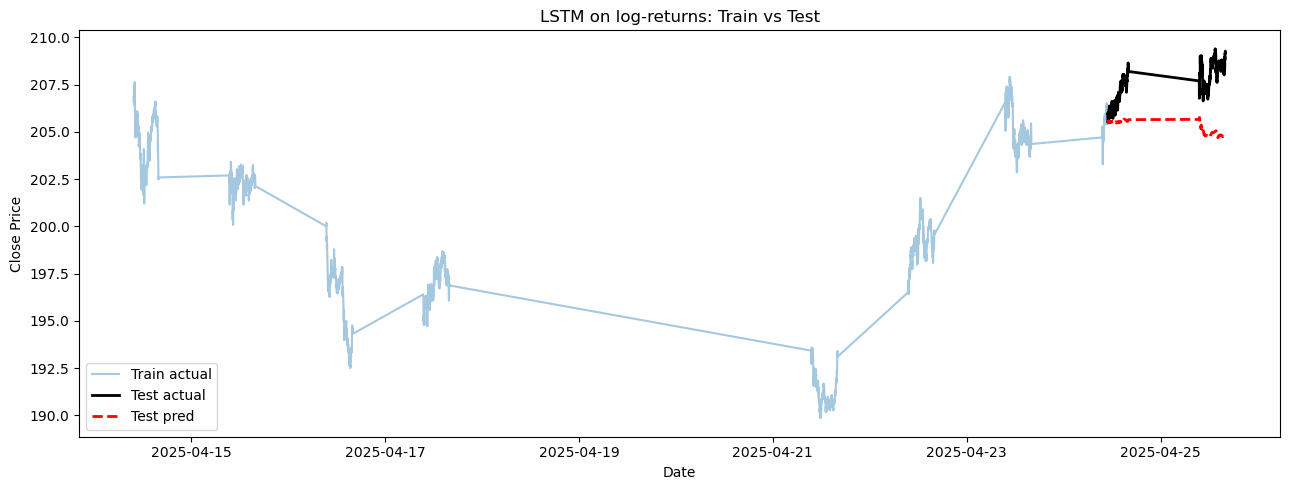


=== Retrain on full data for forecasting ===
Epoch 1/50


/opt/miniconda3/envs/CQC24/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8436
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8423
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8419
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8418
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8418
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8423
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8435
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8433
Epoch 9/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8441
Epoch 10/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8441
Epoch 11/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8439
Epoch 12/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8437
Epoch 13/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8417
Epoch 14/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8368
Epoch 15/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8318


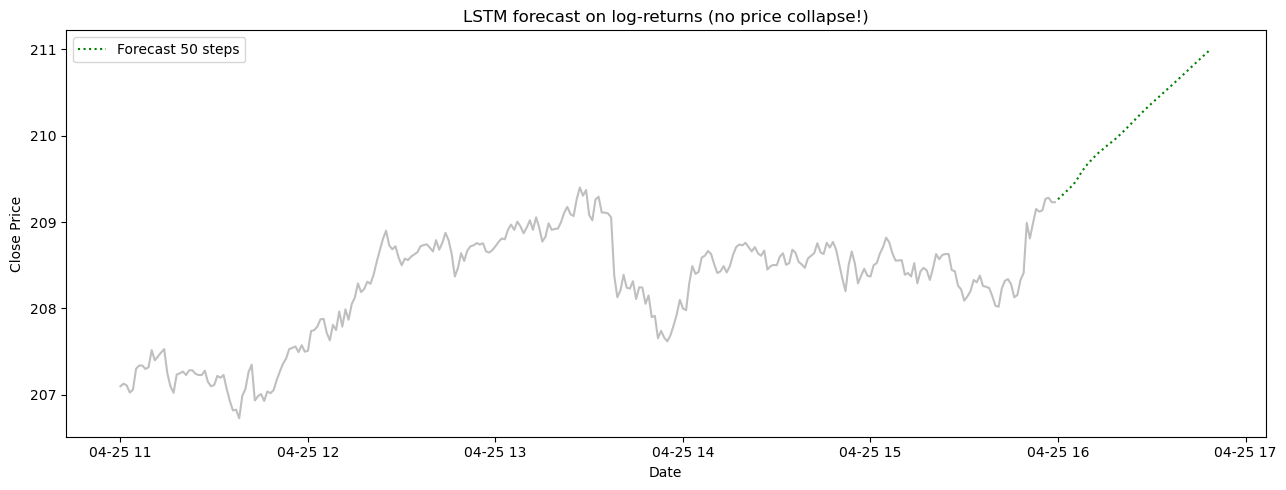


Next few predicted closes:
2025-04-25 16:00:00    209.263921
2025-04-25 16:01:00    209.297973
2025-04-25 16:02:00    209.331930
2025-04-25 16:03:00    209.367091
2025-04-25 16:04:00    209.401933
Freq: min, Name: Pred_Close, dtype: float64


In [17]:
## DECENT PREDICTION BAD RMSE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ───────────────────────── 1. Load data ────────────────────────────────────────
PATH = "HistoricalData/AAPL_ohlc_data.csv"          # <-- change if needed
df = (
    pd.read_csv(PATH, parse_dates=["DATE_TIME"])
      .sort_values("DATE_TIME")
      .set_index("DATE_TIME")
)

# ───────────────────────── 2. Compute log-returns ──────────────────────────────
df["log_ret"] = np.log(df["CLOSE_PRICE"]).diff()      # r_t = log(P_t) – log(P_{t-1})
df = df.dropna()                                      # first row has NaN return

series = df["log_ret"].values.reshape(-1, 1)

# ───────────────────────── 3. Scaling ──────────────────────────────────────────
scaler = StandardScaler()
series_s = scaler.fit_transform(series)

# ───────────────────────── 4. Build sliding windows ────────────────────────────
WINDOW = 20      # 20 past returns → predict next return

def make_dataset(arr, window):
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i : i + window, 0])
        y.append(arr[i + window, 0])
    return np.array(X), np.array(y)

X, y = make_dataset(series_s, WINDOW)
X = X.reshape(-1, WINDOW, 1)          # (samples, timesteps, features)

# ───────────────────────── 5. Train / test split ───────────────────────────────
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

# ───────────────────────── 6. Model builder ────────────────────────────────────
def build_model():
    m = Sequential(
        [
            LSTM(50, return_sequences=True, input_shape=(WINDOW, 1)),
            LSTM(25),
            Dense(1),
        ]
    )
    m.compile(optimizer="adam", loss="mse")
    return m

# ───────────────────────── 7. Fit on training only ─────────────────────────────
model = build_model()
es = EarlyStopping("val_loss", patience=10, restore_best_weights=True)

print("\n=== Fit on training split ===")
model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[es],
    verbose=1,
)

# ───────────────────────── 8. Evaluate level MSE ───────────────────────────────
def inv_scaled(a):                      # helper: scaled → log-return
    return scaler.inverse_transform(a.reshape(-1, 1)).flatten()

# predictions (still in scaled return space)
train_pred_s = model.predict(X_train).flatten()
test_pred_s  = model.predict(X_test).flatten()

# inverse-scale to real log-returns
train_pred_r = inv_scaled(train_pred_s)
test_pred_r  = inv_scaled(test_pred_s)
y_train_r    = inv_scaled(y_train)
y_test_r     = inv_scaled(y_test)

# convert returns to price for MSE (optional but intuitive):
def returns_to_price(start_price, returns):
    prices = [start_price]
    for r in returns:
        prices.append(prices[-1] * np.exp(r))
    return np.array(prices[1:])

# anchor each segment at its own “last known” price
anchor_train = df["CLOSE_PRICE"].iloc[WINDOW - 1]
anchor_test  = df["CLOSE_PRICE"].iloc[WINDOW + len(train_pred_r) - 1]

train_pred_p = returns_to_price(anchor_train, train_pred_r)
y_train_p    = returns_to_price(anchor_train, y_train_r)
test_pred_p  = returns_to_price(anchor_test, test_pred_r)
y_test_p     = returns_to_price(anchor_test, y_test_r)

print(f"\nTrain MSE (price level): {mean_squared_error(y_train_p, train_pred_p):.4f}")
print(f" Test MSE (price level): {mean_squared_error(y_test_p,  test_pred_p):.4f}")

# ───────────────────────── 9. Plot train / test results ────────────────────────
plt.figure(figsize=(13, 5))
# indices
idx_train = df.index[WINDOW : WINDOW + len(train_pred_p)]
idx_test  = df.index[WINDOW + len(train_pred_p) : WINDOW + len(train_pred_p) + len(test_pred_p)]

plt.plot(idx_train, y_train_p, label="Train actual", alpha=0.4)
plt.plot(idx_test, y_test_p, label="Test actual", color="black", linewidth=2)
plt.plot(idx_test, test_pred_p, label="Test pred", color="red", linestyle="--", linewidth=2)

plt.title("LSTM on log-returns: Train vs Test")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

# ───────────────────────── 10. Retrain on full series ──────────────────────────
print("\n=== Retrain on full data for forecasting ===")
model_full = build_model()
es_full = EarlyStopping("loss", patience=10, restore_best_weights=True)
model_full.fit(X, y, epochs=100, batch_size=32, callbacks=[es_full], verbose=1)
print("Full-data fit complete.")

# ───────────────────────── 11. Multi-step forecast (recursive) ─────────────────
FUTURE_STEPS = 50                         # change as needed

history_s = list(series_s[-WINDOW:, 0])    # last WINDOW scaled returns
future_s  = []

for _ in range(FUTURE_STEPS):
    x = np.array(history_s[-WINDOW:]).reshape(1, WINDOW, 1)
    nxt = model_full.predict(x, verbose=0)[0, 0]
    future_s.append(nxt)
    history_s.append(nxt)

# inverse-scale to real log-returns
future_r = inv_scaled(np.array(future_s))

# convert to price path
last_price = df["CLOSE_PRICE"].iloc[-1]
future_p = returns_to_price(last_price, future_r)

# build timeline with the same frequency as original data
freq = pd.infer_freq(df.index) or (df.index[1] - df.index[0])
future_idx = pd.date_range(df.index[-1] + freq, periods=FUTURE_STEPS, freq=freq)

# ───────────────────────── 12. Plot forecast ───────────────────────────────────
plt.figure(figsize=(13, 5))
# show last part of actual data for context
lookback_days = 300
plt.plot(df.index[-lookback_days:], df["CLOSE_PRICE"].iloc[-lookback_days:], color="grey", alpha=0.5)

# future
plt.plot(future_idx, future_p, color="green", linestyle=":", label=f"Forecast {FUTURE_STEPS} steps")

plt.title("LSTM forecast on log-returns (no price collapse!)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

# ───────────────────────── 13. Print numeric forecast (optional) ───────────────
forecast_series = pd.Series(future_p, index=future_idx, name="Pred_Close")
print("\nNext few predicted closes:")
print(forecast_series.head())
